In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("sales_data.csv")
df.head()

,Productid,OrderId,UnitsSold,Sales,SaleDate,Store,Region
0,100,1016,1,7329,2022-02-23,Store4,E
1,100,1006,1,24258,2022-04-03,Store3,N
2,100,1003,23,557934,2022-06-21,Store3,N
3,100,1012,1,11362,2022-06-30,Store7,E
4,100,1013,13,95277,2022-09-02,Store4,E


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Productid  1490 non-null   int64 
 1   OrderId    1490 non-null   int64 
 2   UnitsSold  1490 non-null   int64 
 3   Sales      1490 non-null   int64 
 4   SaleDate   1490 non-null   object
 5   Store      1490 non-null   object
 6   Region     1490 non-null   object
dtypes: int64(4), object(3)
memory usage: 81.6+ KB


In [ ]:
df["SaleDate"] = pd.to_datetime(df["SaleDate"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Productid  1490 non-null   int64         
 1   OrderId    1490 non-null   int64         
 2   UnitsSold  1490 non-null   int64         
 3   Sales      1490 non-null   int64         
 4   SaleDate   1490 non-null   datetime64[ns]
 5   Store      1490 non-null   object        
 6   Region     1490 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 81.6+ KB


In [ ]:
df.isnull().sum()

,0
Productid,0
OrderId,0
UnitsSold,0
Sales,0
SaleDate,0
Store,0
Region,0


In [ ]:
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 668119032


In [ ]:
total_units = df["UnitsSold"].sum()
print("Total Units Sold:", total_units)

Total Units Sold: 19029


In [ ]:
average_sales = df["Sales"].mean()
print("Average Sales per Record:", average_sales)

Average Sales per Record: 448402.03489932884


In [ ]:
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)

Region
E    165064930
N    171678918
S    155099624
W    176275560
Name: Sales, dtype: int64


In [ ]:
region_count = df["Region"].value_counts()
print(region_count)

Region
W    389
E    388
N    371
S    342
Name: count, dtype: int64


In [ ]:
region_avg = df.groupby("Region")["Sales"].mean()
print(region_avg)

Region
E    425425.077320
N    462746.409704
S    453507.672515
W    453150.539846
Name: Sales, dtype: float64


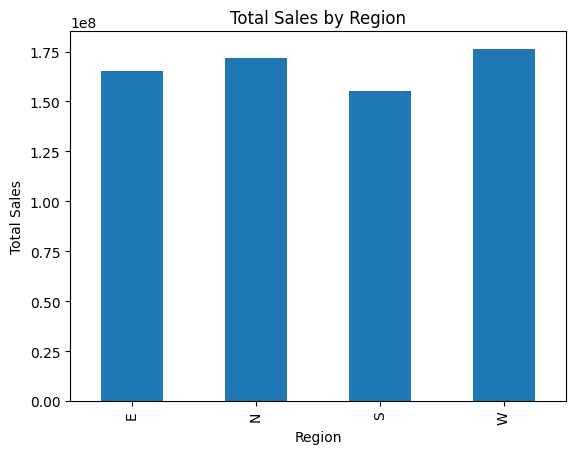

In [ ]:
import matplotlib.pyplot as plt

region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
print("Start Date:", df["SaleDate"].min())
print("End Date:", df["SaleDate"].max())

Start Date: 2021-02-19 00:00:00
End Date: 2024-04-30 00:00:00


In [ ]:
monthly_sales = df.groupby(
    df["SaleDate"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.head(10)

,Sales
SaleDate,
2021-02,388867
2021-04,1256762
2021-05,399192
2021-06,2250600
2021-07,129956
2021-08,2123404
2021-09,1468575
2021-10,1296905
2021-11,1263054


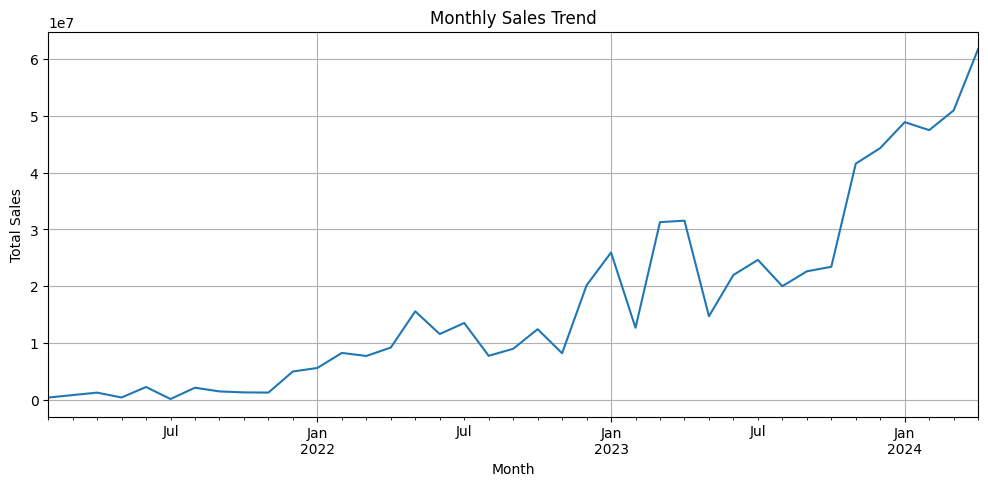

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", figsize=(12,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

In [ ]:
highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print("Highest Monthly Sales:", highest_sales)


Highest Sales Month: 2024-04
Highest Monthly Sales: 61752780


In [ ]:
lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print("Lowest Sales Month:", lowest_month)
print("Lowest Monthly Sales:", lowest_sales)

Lowest Sales Month: 2021-07
Lowest Monthly Sales: 129956


In [ ]:
yearly_sales = df.groupby(df["SaleDate"].dt.year)["Sales"].sum()

print(yearly_sales)

SaleDate
2021     15557750
2022    128887296
2023    314621329
2024    209052657
Name: Sales, dtype: int64


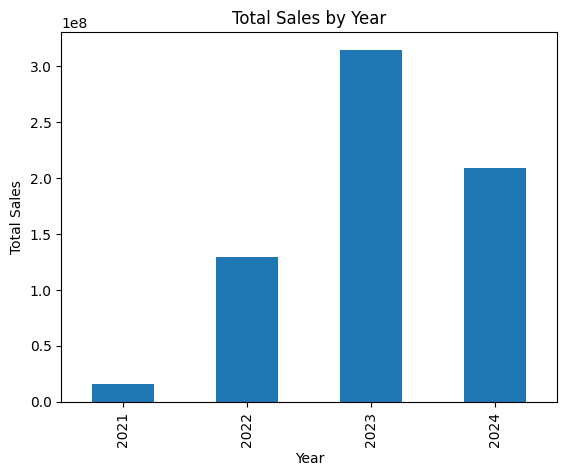

In [ ]:
yearly_sales.plot(kind="bar")

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
df["Month"] = df["SaleDate"].dt.month

monthly_avg = df.groupby("Month")["Sales"].mean()

print(monthly_avg)

Month
1     487252.727273
2     393036.040000
3     445203.118812
4     491623.587678
5     414573.405405
6     470982.815789
7     539103.028169
8     382759.102564
9     408091.382716
10    386802.927083
11    447680.394737
12    472440.265306
Name: Sales, dtype: float64


In [ ]:
monthly_year_sales = df.pivot_table(
    values="Sales",
    index=df["SaleDate"].dt.month,
    columns=df["SaleDate"].dt.year,
    aggfunc="mean"
)

print(monthly_year_sales)

SaleDate          2021           2022           2023           2024
SaleDate                                                           
1                  NaN  430391.076923  529058.571429  474541.223301
2         1.944335e+05  412344.350000  294749.674419  431557.427273
3                  NaN  481828.062500  679803.630435  363934.385714
4         3.141905e+05  612771.400000  573299.345455  450750.218978
5         9.979800e+04  648816.041667  319731.630435            NaN
6         2.250600e+06  462844.200000  439459.780000            NaN
7         1.299560e+05  675972.700000  492538.100000            NaN
8         5.308510e+05  407420.105263  363469.527273            NaN
9         1.468575e+06  373863.916667  403823.089286            NaN
10        2.593810e+05  388285.750000  396797.152542            NaN
11        4.210180e+05  372515.909091  467159.112360            NaN
12        4.527668e+05  491418.317073  466527.715789            NaN


In [ ]:
store_sales = df.groupby("Store")["Sales"].sum().sort_values(ascending=False)

print(store_sales)

Store
Store2    176275560
Store3     98496441
Store4     96124741
Store5     89116829
Store1     73182477
Store7     68940189
Store6     65982795
Name: Sales, dtype: int64


In [ ]:
store_region = df.groupby(["Region", "Store"])["Sales"].sum()

print(store_region)

Region  Store 
E       Store4     96124741
        Store7     68940189
N       Store1     73182477
        Store3     98496441
S       Store5     89116829
        Store6     65982795
W       Store2    176275560
Name: Sales, dtype: int64


In [ ]:
product_sales = df.groupby("Productid")["Sales"].sum().sort_values(ascending=False)

print(product_sales.head(10))

Productid
128    25905418
142    25516700
127    24028787
134    23674405
143    21926274
131    20726210
139    20698886
140    18819020
158    18278491
146    17323780
Name: Sales, dtype: int64


In [ ]:
product_analysis = df.groupby("Productid").agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("UnitsSold", "sum")
).sort_values("Total_Sales", ascending=False)

print(product_analysis.head(10))

           Total_Sales  Total_Units
Productid                          
128           25905418          292
142           25516700          355
127           24028787          327
134           23674405          270
143           21926274          225
131           20726210          230
139           20698886          233
140           18819020          235
158           18278491          421
146           17323780          490


In [ ]:
product_analysis["Sales_Per_Unit"] = (
    product_analysis["Total_Sales"] / product_analysis["Total_Units"]
)

print(product_analysis.head(10))

           Total_Sales  Total_Units  Sales_Per_Unit
Productid                                          
128           25905418          292    88717.184932
142           25516700          355    71878.028169
127           24028787          327    73482.529052
134           23674405          270    87682.981481
143           21926274          225    97450.106667
131           20726210          230    90113.956522
139           20698886          233    88836.420601
140           18819020          235    80080.936170
158           18278491          421    43416.843230
146           17323780          490    35354.653061


In [ ]:
forecast_data = monthly_sales.reset_index()

forecast_data.columns = ["Month", "Sales"]

print(forecast_data.head())
print(forecast_data.tail())

     Month    Sales
0  2021-02   388867
1  2021-04  1256762
2  2021-05   399192
3  2021-06  2250600
4  2021-07   129956
      Month     Sales
33  2023-12  44320133
34  2024-01  48877746
35  2024-02  47471317
36  2024-03  50950814
37  2024-04  61752780


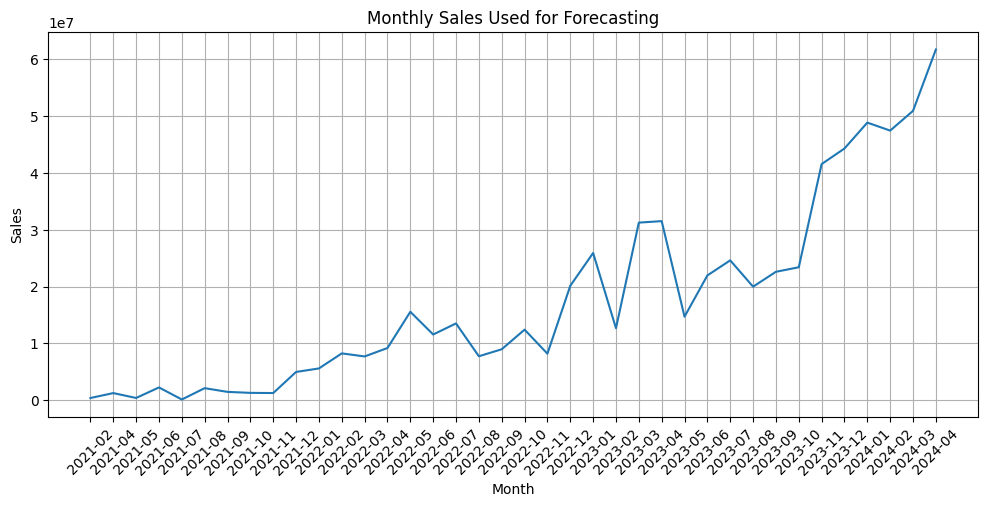

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(forecast_data["Month"].astype(str), forecast_data["Sales"])

plt.title("Monthly Sales Used for Forecasting")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
forecast_data["Month"] = pd.to_datetime(
    forecast_data["Month"].astype(str)
)

forecast_data = forecast_data.set_index("Month")

forecast_data = forecast_data.asfreq("MS")

print(forecast_data[forecast_data["Sales"].isna()])

            Sales
Month            
2021-03-01    NaN


In [ ]:
forecast_data["Sales"] = forecast_data["Sales"].interpolate()

print(forecast_data.loc["2021-02":"2021-04"])

                Sales
Month                
2021-02-01   388867.0
2021-03-01   822814.5
2021-04-01  1256762.0


In [ ]:
forecast_data["Time_Index"] = range(len(forecast_data))

print(forecast_data.head())

                Sales  Time_Index
Month                            
2021-02-01   388867.0           0
2021-03-01   822814.5           1
2021-04-01  1256762.0           2
2021-05-01   399192.0           3
2021-06-01  2250600.0           4


In [ ]:
train = forecast_data.iloc[:-6]
test = forecast_data.iloc[-6:]

print("Training data:")
print(train.tail())

print("\nTesting data:")
print(test)

Training data:
                 Sales  Time_Index
Month                             
2023-06-01  21972989.0          28
2023-07-01  24626905.0          29
2023-08-01  19990824.0          30
2023-09-01  22614093.0          31
2023-10-01  23411032.0          32

Testing data:
                 Sales  Time_Index
Month                             
2023-11-01  41577161.0          33
2023-12-01  44320133.0          34
2024-01-01  48877746.0          35
2024-02-01  47471317.0          36
2024-03-01  50950814.0          37
2024-04-01  61752780.0          38


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
X_train = train[["Time_Index"]]
y_train = train["Sales"]

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(test[["Time_Index"]])

print(predictions)

[26190977.5123106  27064971.02818628 27938964.54406194 28812958.05993761
 29686951.57581328 30560945.09168895]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test["Sales"], predictions)
rmse = np.sqrt(mean_squared_error(test["Sales"], predictions))
r2 = r2_score(test["Sales"], predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 20782363.86466689
RMSE: 21393630.64998625
R2 Score: -10.17945995075076


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
model_hw = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal=None
).fit()

In [ ]:
hw_predictions = model_hw.forecast(steps=6)

print(hw_predictions)

2023-11-01    2.540582e+07
2023-12-01    2.617672e+07
2024-01-01    2.694762e+07
2024-02-01    2.771852e+07
2024-03-01    2.848942e+07
2024-04-01    2.926032e+07
Freq: MS, dtype: float64


In [ ]:
hw_mae = mean_absolute_error(test["Sales"], hw_predictions)
hw_rmse = np.sqrt(mean_squared_error(test["Sales"], hw_predictions))
hw_r2 = r2_score(test["Sales"], hw_predictions)

print("Holt-Winters MAE:", hw_mae)
print("Holt-Winters RMSE:", hw_rmse)
print("Holt-Winters R2:", hw_r2)

Holt-Winters MAE: 21825254.641964454
Holt-Winters RMSE: 22442790.226479515
Holt-Winters R2: -11.30284457202395


In [ ]:
import numpy as np

train_log = np.log1p(train["Sales"])

print(train_log.head())

Month
2021-02-01    12.870995
2021-03-01    13.620487
2021-04-01    14.044050
2021-05-01    12.897200
2021-06-01    14.626708
Freq: MS, Name: Sales, dtype: float64


In [ ]:
from sklearn.linear_model import LinearRegression

log_model = LinearRegression()

X_train = train[["Time_Index"]]

log_model.fit(X_train, train_log)

LinearRegression()

In [ ]:
log_predictions = log_model.predict(test[["Time_Index"]])

# Convert predictions back to original Sales scale
final_predictions = np.expm1(log_predictions)

print(final_predictions)

[5.54538259e+07 6.32324079e+07 7.21021020e+07 8.22159598e+07
 9.37485019e+07 1.06898729e+08]


In [ ]:
log_mae = mean_absolute_error(test["Sales"], final_predictions)
log_rmse = np.sqrt(mean_squared_error(test["Sales"], final_predictions))
log_r2 = r2_score(test["Sales"], final_predictions)

print("Log Linear Regression MAE:", log_mae)
print("Log Linear Regression RMSE:", log_rmse)
print("Log Linear Regression R2:", log_r2)

Log Linear Regression MAE: 29783595.898667257
Log Linear Regression RMSE: 32058788.90673574
Log Linear Regression R2: -24.104181196249762


In [ ]:
print(forecast_data.loc["2023-01":"2024-04", ["Sales"]])

                 Sales
Month                 
2023-01-01  25923870.0
2023-02-01  12674236.0
2023-03-01  31270967.0
2023-04-01  31531464.0
2023-05-01  14707655.0
2023-06-01  21972989.0
2023-07-01  24626905.0
2023-08-01  19990824.0
2023-09-01  22614093.0
2023-10-01  23411032.0
2023-11-01  41577161.0
2023-12-01  44320133.0
2024-01-01  48877746.0
2024-02-01  47471317.0
2024-03-01  50950814.0
2024-04-01  61752780.0


In [ ]:
forecast_data["Moving_Avg_3"] = (
    forecast_data["Sales"]
    .rolling(window=3)
    .mean()
)

print(forecast_data[["Sales", "Moving_Avg_3"]].tail(10))

                 Sales  Moving_Avg_3
Month                               
2023-07-01  24626905.0  2.043585e+07
2023-08-01  19990824.0  2.219691e+07
2023-09-01  22614093.0  2.241061e+07
2023-10-01  23411032.0  2.200532e+07
2023-11-01  41577161.0  2.920076e+07
2023-12-01  44320133.0  3.643611e+07
2024-01-01  48877746.0  4.492501e+07
2024-02-01  47471317.0  4.688973e+07
2024-03-01  50950814.0  4.909996e+07
2024-04-01  61752780.0  5.339164e+07


In [ ]:
next_month_forecast = (
    forecast_data["Sales"]
    .tail(3)
    .mean()
)

print("Next Month Forecast:", next_month_forecast)

Next Month Forecast: 53391637.0
